# 00 · Negocio, arquitectura crediticia y población — Caso 15 · Caja Rural 360

**Alcance:** evidencia cuantitativa de las secciones **6.1** (entendimiento del negocio y arquitectura crediticia) y **6.2** (definición del modelo y población) del Trabajo Integrador Final.

La narrativa completa está en `reports/01_negocio_y_arquitectura_crediticia.md` y `reports/02_definicion_modelo_y_poblacion.md`; este notebook produce las cifras, tablas (`reports/tables/`) y figuras (`reports/figures/`) que esos documentos citan. Las definiciones (target, filtros, split temporal, catálogo de variables, Risk Appetite) no se escriben aquí: se importan de `src/` para que todo el proyecto use exactamente la misma versión.

| Sección | Contenido |
|---|---|
| 1 | Carga y vista general del dataset |
| 2 | Perfil del producto y del cliente objetivo |
| 3 | Ciclo de crédito end-to-end y punto de consumo del modelo |
| 4 | Línea base histórica: aprobación, default, pérdida, estacionalidad |
| 5 | Sesgo de selección de la política histórica |
| 6 | Capacidad de pago y Risk Appetite |
| 7 | Target, población elegible y exclusiones |
| 8 | Esquema temporal DEV / VAL / OOT |
| 9 | Variables disponibles en el momento de la decisión |
| 10 | Persistencia de la población y resumen de decisiones |

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import config as cfg, data, diagrams, risk_appetite, validation

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
for d in (cfg.FIGURES, cfg.TABLES, cfg.DATA_PROCESSED):
    d.mkdir(parents=True, exist_ok=True)

# Paleta de referencia validada (<= 3 series categóricas) y tinta/ejes recesivos.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
SAMPLE_COLORS = {"DEV": BLUE, "VAL": ORANGE, "OOT": AQUA}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.grid": True, "grid.color": GRID, "grid.linestyle": "-",
    "grid.linewidth": 0.6, "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9.5, "legend.frameon": False, "figure.dpi": 100,
})

def savefig(fig, name):
    fig.savefig(cfg.FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")

def pct_axis(ax, axis="y", decimals=0):
    a = ax.yaxis if axis == "y" else ax.xaxis
    a.set_major_locator(plt.MaxNLocator(nbins=6, steps=[1, 2, 5, 10]))
    a.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.{decimals}%}"))

print("Raíz del repositorio:", ROOT)

Raíz del repositorio: c:\Users\USUARIO\Downloads\Proyecto_Final_Credit_Scoring\credit-risk-capstone


## 1. Carga y vista general

In [31]:
raw = data.load_raw()
dic = data.load_dictionary()
RAW_COLS = list(raw.columns)          # columnas originales (la población se construye solo con ellas)
raw["year"] = raw[cfg.DATE_COL].dt.year

print(f"Filas: {len(raw):,} | Columnas: {raw.shape[1] - 1} | Periodo: {raw[cfg.DATE_COL].min():%Y-%m-%d} a {raw[cfg.DATE_COL].max():%Y-%m-%d}")
print("Entidad:", raw["entity"].unique()[0], "| Producto:", raw["product"].unique()[0])
print("IDs duplicados:", raw[cfg.ID_COL].duplicated().sum(), "| Filas duplicadas (sin ID):", raw.drop(columns=cfg.ID_COL).duplicated().sum())
empty = [c for c in raw.columns if raw[c].isna().all()]
print("Columnas 100% vacías (no aplican al producto):", empty)

Filas: 7,000 | Columnas: 41 | Periodo: 2021-01-01 a 2025-12-27
Entidad: Caja Rural 360 | Producto: Microcredito rural para independientes
IDs duplicados: 0 | Filas duplicadas (sin ID): 0
Columnas 100% vacías (no aplican al producto): ['collateral_value', 'ltv', 'credit_limit', 'balance_at_observation', 'utilization_at_observation', 'undrawn_amount_at_observation', 'ccf_observed']


Siete columnas están 100% vacías: son campos de productos **garantizados** (`collateral_value`, `ltv`) o **revolventes** (`credit_limit`, `balance_at_observation`, `utilization_at_observation`, `undrawn_amount_at_observation`, `ccf_observed`). Esto confirma que el microcrédito de Caja Rural 360 es **sin garantía real**.

In [33]:
default_counts = raw.loc[raw["outcome_available_flag"] == 1, "default_12m_flag"].value_counts().rename({0: "No default (0)", 1: "Default (1)"})
default_pct = raw.loc[raw["outcome_available_flag"] == 1, "default_12m_flag"].value_counts(normalize=True).rename({0: "No default (0)", 1: "Default (1)"})
display(pd.DataFrame({"registros": default_counts, "% del total con outcome": default_pct}))

,registros,% del total con outcome
default_12m_flag,,
No default (0),5112,0.8840
Default (1),671,0.1160


Presentamos 671 registros de clientes que cayeron en Default y 5112 registros de clientes que no cayeron en default

In [35]:
print("En los rechazados (outcome_available_flag=0), default_12m_flag=0 es un valor técnico, no un resultado observado.")
display(pd.crosstab(raw["outcome_available_flag"], raw["default_12m_flag"], margins=True, margins_name="Total"))

En los rechazados (outcome_available_flag=0), default_12m_flag=0 es un valor técnico, no un resultado observado.


default_12m_flag,0,1,Total
outcome_available_flag,,,
0,1217,0,1217
1,5112,671,5783
Total,6329,671,7000


De las 7,000 solicitudes, 1,217 fueron **rechazadas** (`outcome_available_flag = 0`) y no tienen resultado observado: su `default_12m_flag = 0`, por eso quedan fuera del análisis de default.

De las 5,783 solicitudes **aprobadas y con resultado observado** (`outcome_available_flag = 1`), 5,112 no llegaron a 90 días de mora (no default) y 671 sí (default), lo que da una tasa de default del **11.60%** (671 / 5,783). Esta es la población y la tasa que se usarán para desarrollar el modelo PD.

In [32]:
missing = raw.isna().mean()
display(missing[(missing > 0) & (missing < 1)].sort_values(ascending=False).rename("% faltante").to_frame())

,% faltante
balance_at_default,0.9041
months_to_recovery,0.9041
ead_at_default,0.9041
recovery_cost_total,0.9041
recovery_amount_total,0.9041
lgd_observed,0.9041
savings_balance,0.0771
bureau_score,0.0327
monthly_income,0.0243


Los campos post-default (≈90% vacíos) solo existen para los 671 créditos que entraron en default. Entre las variables pre-originación, los faltantes están en `savings_balance` (7.7%), `bureau_score` (3.3%) y `monthly_income` (2.4%).

## 2. Perfil del producto y del cliente objetivo (6.1)

In [42]:
num_cols = ["requested_amount", "term_months", "annual_interest_rate_offer", "monthly_income", "dti",
            "bureau_score", "cash_income_share", "distance_to_branch_km", "household_dependents", "age",
            "employment_tenure_months", "relationship_months"]
product_profile = (raw[num_cols].describe(percentiles=[.05, .25, .5, .75, .95])
                   .T[["count", "mean", "std", "5%", "25%", "50%", "75%", "95%", "max", "min"]])
display(product_profile)

,count,mean,std,5%,25%,50%,75%,95%,max,min
requested_amount,"7,000.0000","7,891.7045","5,991.5501","2,064.7645","3,935.9275","6,309.0800","10,004.8750","18,936.7495","78,915.4700",512.0100
term_months,"7,000.0000",26.2873,18.1776,6.0000,9.0000,18.0000,36.0000,60.0000,60.0000,6.0000
annual_interest_rate_offer,"7,000.0000",0.2951,0.0724,0.1818,0.2454,0.2927,0.3403,0.4190,0.6387,0.0897
monthly_income,"6,830.0000","4,119.2720","2,542.6412","1,348.9025","2,361.0800","3,497.0200","5,232.0625","8,909.7420","33,678.1500",529.2300
dti,"7,000.0000",0.2857,0.1602,0.0632,0.1593,0.2647,0.3889,0.5839,0.8590,0.0024
bureau_score,"6,771.0000",665.2093,74.4098,540.0000,616.0000,667.0000,716.0000,788.0000,850.0000,379.0000
cash_income_share,"7,000.0000",0.5961,0.2010,0.2471,0.4473,0.6113,0.7544,0.8978,0.9963,0.0147
distance_to_branch_km,"7,000.0000",12.2104,11.3667,2.3000,5.2000,9.0000,15.2000,32.8050,150.0000,0.5000
household_dependents,"7,000.0000",2.1977,1.4688,0.0000,1.0000,2.0000,3.0000,5.0000,8.0000,0.0000
age,"7,000.0000",38.1126,9.7250,21.0000,32.0000,38.0000,45.0000,54.0500,72.0000,18.0000


El monto solicitado tiene una mediana de S/ 6,309, con el 90% de las solicitudes entre S/ 2,065 y S/ 18,937: es un ticket de microcrédito. El plazo va de 6 a 60 meses. La tasa ofrecida tiene una mediana de 29.3% anual.

El cliente típico cobra en promedio el 60% de su ingreso en efectivo (`cash_income_share`) y vive a una mediana de 9 km de la agencia más cercana, aunque el 5% más alejado supera los 33 km (p95). El score de buró está disponible para la gran mayoría (6,771 de 7,000; el resto, 3.3%, es thin-file) y tiene una mediana de 667 puntos.

In [43]:
cat_profile = pd.concat({c: raw[c].value_counts(normalize=True) for c in ["channel", "region", "employment_type"]})
display(cat_profile.rename("% solicitudes").to_frame())

client_flags = pd.Series({
    "Canales digitales (web + app)": raw["channel"].isin(["web", "app"]).mean(),
    "Clientes nuevos (sin relación previa)": raw["new_customer_flag"].mean(),
    "Sin score de buró (thin-file)": raw["bureau_score"].isna().mean(),
    "Ingreso en efectivo > 80%": raw["cash_income_share"].gt(cfg.HIGH_CASH_SHARE).mean(),
    "Distancia a agencia > 50 km": raw["distance_to_branch_km"].gt(cfg.REMOTE_DISTANCE_KM).mean(),
    "Plazo <= 12 meses": raw["term_months"].le(12).mean(),
    "Plazo > 36 meses": raw["term_months"].gt(cfg.LONG_TERM_MONTHS).mean(),
    "Monto > S/ 20,000": raw["requested_amount"].gt(cfg.MICRO_MAX_AUTO_AMOUNT).mean(),
}, name="% solicitudes")
display(client_flags.to_frame())
product_profile.to_csv(cfg.TABLES / "perfil_producto_numerico.csv")

% solicitudes
channel         web                   0.3487
                app                   0.3383
                agencia               0.2177
                alianza               0.0953
region          Lima                  0.4099
                Norte                 0.1886
                Centro                0.1533
                Sur                   0.1487
                Oriente               0.0996
employment_type dependiente           0.5287
                independiente         0.3121
                temporal              0.0876
                empresa               0.0716

,% solicitudes
Canales digitales (web + app),0.6870
Clientes nuevos (sin relación previa),0.4450
Sin score de buró (thin-file),0.0327
Ingreso en efectivo > 80%,0.1786
Distancia a agencia > 50 km,0.0151
Plazo <= 12 meses,0.3800
Plazo > 36 meses,0.2409
"Monto > S/ 20,000",0.0420


El canal de originación ya es mayoritariamente digital: 68.7% de las solicitudes llega por web o app, frente a 21.8% por agencia y 9.5% por alianzas. Esto confirma que el crecimiento "fuera de agencias" no es una meta futura, sino la operación actual, y el modelo debe sostenerla.

Lima concentra el 41.0% de las solicitudes, seguida de Norte (18.9%) y Centro (15.3%).

El 52.9% de `employment_type` figura como "dependiente", aunque el producto está dirigido a independientes. Se interpreta como la actividad principal declarada del hogar rural (por ejemplo, jornaleros o asalariados agrícolas con actividad independiente complementaria); no se excluye a nadie por esta variable, y queda registrado como supuesto.

Los segmentos de mayor riesgo operativo son minoritarios: 3.3% sin score de buró, 17.9% con más de 80% de ingreso en efectivo y solo 1.5% a más de 50 km de una agencia. El 38.0% de las solicitudes tiene plazo de 12 meses o menos, frente a un 24.1% que supera los 36 meses, y apenas el 4.2% pide montos mayores a S/ 20,000.

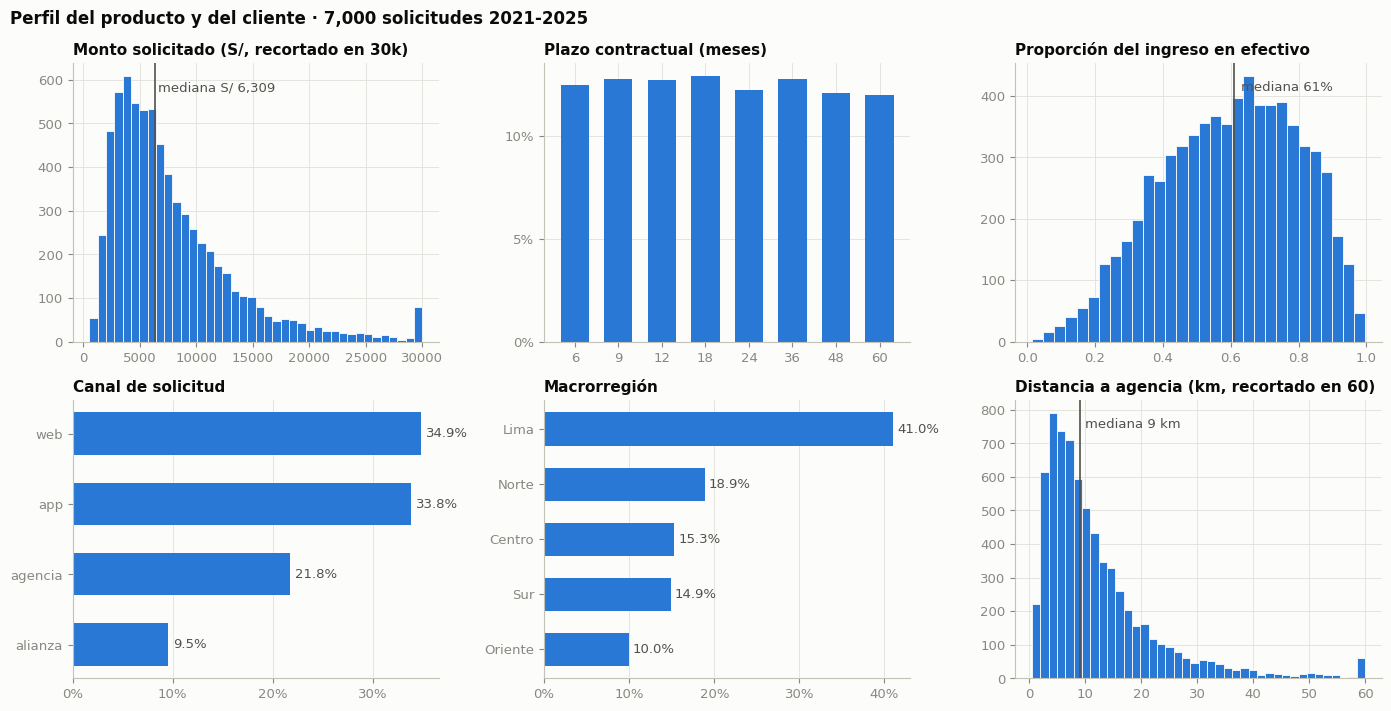

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7.2))
ax = axes[0, 0]
ax.hist(raw["requested_amount"].clip(upper=30000), bins=40, color=BLUE, edgecolor=SURFACE, linewidth=0.6)
ax.axvline(raw["requested_amount"].median(), color=INK_2, lw=1.2)
ax.set_title("Monto solicitado (S/, recortado en 30k)")
ax.text(raw["requested_amount"].median() * 1.05, ax.get_ylim()[1] * 0.9, f"mediana S/ {raw['requested_amount'].median():,.0f}", color=INK_2)

ax = axes[0, 1]
t = raw["term_months"].value_counts(normalize=True).sort_index()
ax.bar(t.index.astype(int).astype(str), t.values, color=BLUE, width=0.65)
ax.set_title("Plazo contractual (meses)"); pct_axis(ax)

ax = axes[0, 2]
ax.hist(raw["cash_income_share"], bins=30, color=BLUE, edgecolor=SURFACE, linewidth=0.6)
ax.axvline(raw["cash_income_share"].median(), color=INK_2, lw=1.2)
ax.set_title("Proporción del ingreso en efectivo")
ax.text(raw["cash_income_share"].median() + 0.02, ax.get_ylim()[1] * 0.9, f"mediana {raw['cash_income_share'].median():.0%}", color=INK_2)

for ax, col, title in [(axes[1, 0], "channel", "Canal de solicitud"), (axes[1, 1], "region", "Macrorregión")]:
    t = raw[col].value_counts(normalize=True).sort_values()
    ax.barh(t.index, t.values, color=BLUE, height=0.6)
    for y, v in enumerate(t.values):
        ax.text(v + 0.005, y, f"{v:.1%}", va="center", color=INK_2)
    ax.set_title(title); pct_axis(ax, "x"); ax.grid(axis="y", visible=False)

ax = axes[1, 2]
ax.hist(raw["distance_to_branch_km"].clip(upper=60), bins=40, color=BLUE, edgecolor=SURFACE, linewidth=0.6)
ax.axvline(raw["distance_to_branch_km"].median(), color=INK_2, lw=1.2)
ax.set_title("Distancia a agencia (km, recortado en 60)")
ax.text(raw["distance_to_branch_km"].median() + 1, ax.get_ylim()[1] * 0.9, f"mediana {raw['distance_to_branch_km'].median():.0f} km", color=INK_2)
fig.suptitle("Perfil del producto y del cliente · 7,000 solicitudes 2021-2025", x=0.01, ha="left", fontweight="bold", fontsize=12)
fig.tight_layout()
savefig(fig, "fig02_perfil_producto_cliente")
plt.show()

El monto solicitado se concentra en tickets bajos (mediana S/ 6,309), con una larga cola de montos altos y un pequeño repunte en el límite superior (S/ 30,000). El plazo se reparte de forma casi uniforme entre las 8 opciones disponibles (6 a 60 meses). La proporción de ingreso en efectivo tiene su pico alrededor del 60-65%, confirmando que la mayoría de clientes cobra gran parte de su ingreso de manera informal.

Por canal, web y app concentran juntos el 68.7% de las solicitudes, muy por encima de agencia (21.8%) y alianza (9.5%). Por macrorregión, Lima domina con 41.0%, seguida de Norte (18.9%). La distancia a la agencia más cercana tiene una mediana de solo 9 km, aunque con una cola larga hasta 60 km (recortada en el gráfico) que incluye al segmento más alejado y costoso de atender.


## 3. Ciclo de crédito end-to-end y punto de consumo del modelo (6.1)

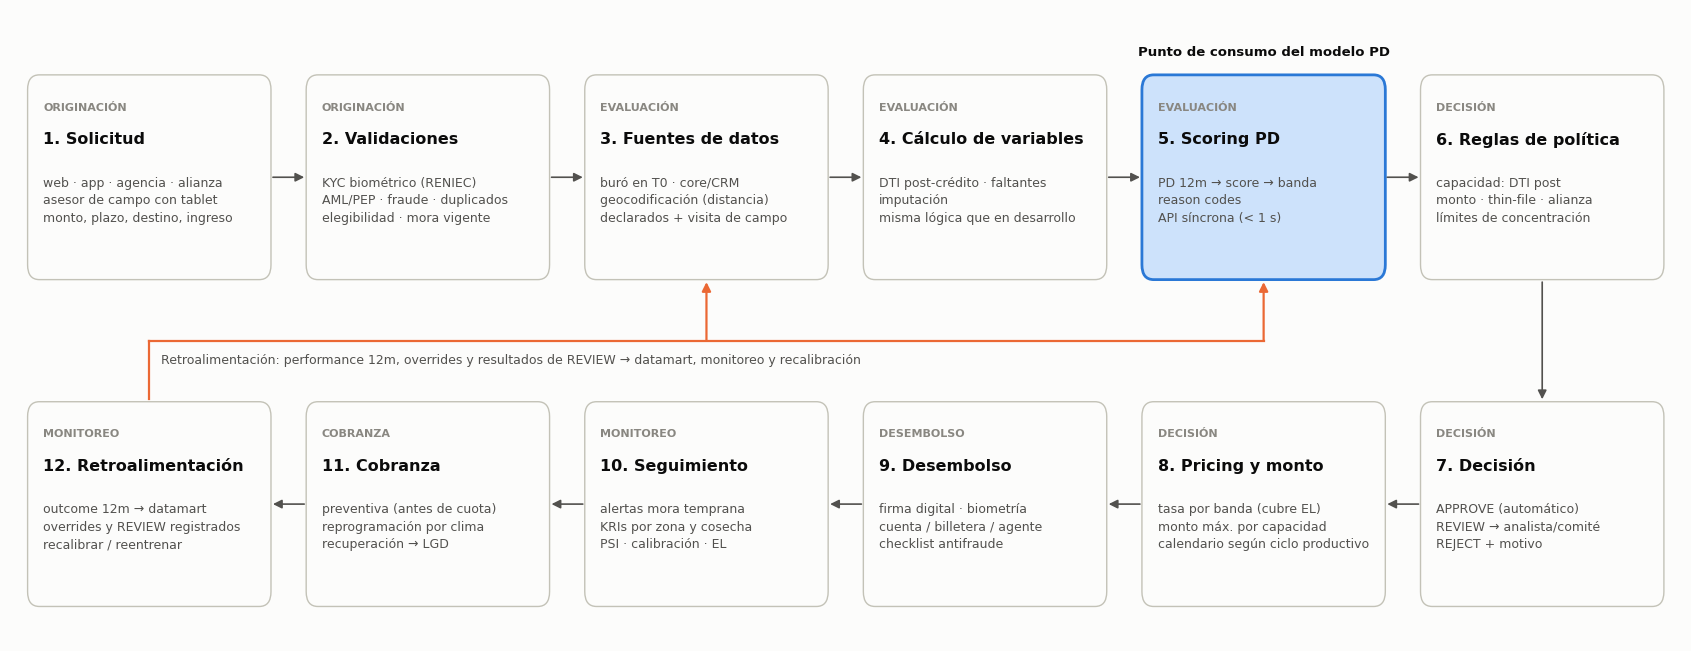

In [6]:
fig = diagrams.plot_credit_cycle(cfg.FIGURES / "fig01_ciclo_credito.png")
plt.show()

El modelo PD de originación se consume en el **paso 5**, de forma síncrona vía API, **después** de los knock-outs (KYC, fraude, elegibilidad) y del enriquecimiento de datos, y **antes** de las reglas de capacidad de pago, la decisión y el pricing. Su salida (PD 12m, score, banda y reason codes) alimenta tres decisiones: APPROVE/REVIEW/REJECT (paso 7), tasa y monto máximo (paso 8) y el cálculo de Expected Loss para el apetito de riesgo. El detalle de cada etapa está en `reports/01_negocio_y_arquitectura_crediticia.md`.

## 4. Línea base histórica (insumo del Risk Appetite)

In [7]:
perf = raw[raw[cfg.OUTCOME_FILTER].eq(1)].copy()
perf["loss_realized"] = perf["ead_at_default"].fillna(0) * perf["lgd_observed"].fillna(0)
dflt = perf[perf[cfg.TARGET].eq(1)]

def baseline(apps, p, d):
    return pd.Series({
        "solicitudes": len(apps),
        "aprobacion_ttd": apps[cfg.APPROVED_FLAG].mean(),
        "creditos_con_outcome": len(p),
        "defaults": int(p[cfg.TARGET].sum()),
        "default_rate_12m": p[cfg.TARGET].mean(),
        "monto_desembolsado": p["requested_amount"].sum(),
        "ead_default_sobre_monto": (d["ead_at_default"] / d["requested_amount"]).mean(),
        "lgd_media": d["lgd_observed"].mean(),
        "meses_recuperacion": d["months_to_recovery"].mean(),
        "perdida_realizada_sobre_monto": p["loss_realized"].sum() / p["requested_amount"].sum(),
    })

annual = pd.DataFrame({y: baseline(raw[raw.year == y], perf[perf.year == y], dflt[dflt.year == y])
                       for y in sorted(raw.year.unique())}).T
annual.loc["2021-2025"] = baseline(raw, perf, dflt)
display(annual)
annual.to_csv(cfg.TABLES / "linea_base_anual.csv")

,solicitudes,aprobacion_ttd,creditos_con_outcome,defaults,default_rate_12m,monto_desembolsado,ead_default_sobre_monto,lgd_media,meses_recuperacion,perdida_realizada_sobre_monto
2021,"1,392.0000",0.8484,"1,181.0000",102.0000,0.0864,"9,036,530.5800",0.3956,0.6193,12.0882,0.0189
2022,"1,380.0000",0.8304,"1,146.0000",111.0000,0.0969,"8,760,929.9000",0.4253,0.6156,11.5135,0.0234
2023,"1,382.0000",0.8075,"1,116.0000",138.0000,0.1237,"8,965,184.7600",0.4220,0.6149,12.6449,0.0300
2024,"1,389.0000",0.8287,"1,151.0000",161.0000,0.1399,"9,157,698.6800",0.4099,0.6260,12.1925,0.0401
2025,"1,457.0000",0.8161,"1,189.0000",159.0000,0.1337,"9,627,980.4100",0.4301,0.6339,11.4025,0.0337
2021-2025,"7,000.0000",0.8261,"5,783.0000",671.0000,0.1160,"45,548,324.3300",0.4176,0.6229,11.9702,0.0293


La aprobación se mantiene estable entre 80.8% y 84.8% cada año (82.6% en el total 2021-2025), pero el **default 12m sube de forma sostenida**: de 8.6% en 2021 a 14.0% en 2024, con una leve baja a 13.4% en 2025. La pérdida realizada sobre el monto desembolsado sigue la misma tendencia, de 1.9% a 4.0%.

En cambio, la severidad se mantiene estable en todo el periodo: la LGD media ronda 61%-63% y la exposición al default (`ead_default_sobre_monto`) se mueve entre 40% y 43% del monto solicitado, con un tiempo de recuperación de 11 a 13 meses. Esto indica que **el deterioro viene por el lado de la frecuencia de default, no de la severidad**, y que la política histórica no logró contenerlo pese a mantener aprobación constante.

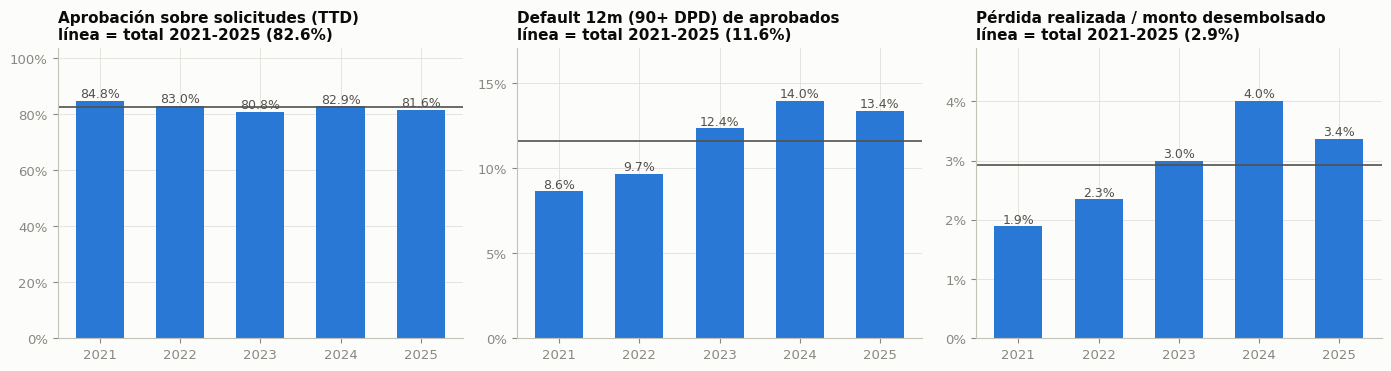

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
years = annual.index[:-1].astype(str)
specs = [("aprobacion_ttd", "Aprobación sobre solicitudes (TTD)"),
         ("default_rate_12m", "Default 12m (90+ DPD) de aprobados"),
         ("perdida_realizada_sobre_monto", "Pérdida realizada / monto desembolsado")]
for ax, (col, title) in zip(axes, specs):
    vals = annual[col].iloc[:-1].values
    ax.bar(years, vals, color=BLUE, width=0.6)
    ax.axhline(annual.loc["2021-2025", col], color=INK_2, lw=1.2)
    for x, v in enumerate(vals):
        ax.text(x, v, f"{v:.1%}", ha="center", va="bottom", color=INK_2, fontsize=9)
    ax.set_title(f"{title}\nlínea = total 2021-2025 ({annual.loc['2021-2025', col]:.1%})"); pct_axis(ax)
    ax.set_ylim(0, max(vals) * 1.22)
fig.tight_layout()
savefig(fig, "fig03_linea_base_anual")
plt.show()

**Hallazgo central para el diseño temporal:** la aprobación histórica es estable (~82%), pero el **default 12m sube de 8.6% (2021) a 14.0% (2024) y 13.4% (2025)**, y la pérdida realizada pasa de 1.9% a 4.0% del monto. La LGD (≈62%) y el factor EAD/monto (≈0.42) son estables: el deterioro viene de la **frecuencia** de default, no de la severidad.

¿Cambió la población o cambió el riesgo? La siguiente tabla responde:

In [9]:
composition = raw.groupby("year")[["bureau_score", "dti", "cash_income_share", "distance_to_branch_km",
                                    "requested_amount", "monthly_income", "new_customer_flag"]].mean()
display(composition)

perf["bureau_quintil"] = pd.qcut(perf["bureau_score"], 5, labels=["Q1 (bajo)", "Q2", "Q3", "Q4", "Q5 (alto)"])
dr_bq_year = perf.pivot_table(index="bureau_quintil", columns="year", values=cfg.TARGET, aggfunc="mean", observed=True)
display(dr_bq_year)

,bureau_score,dti,cash_income_share,distance_to_branch_km,requested_amount,monthly_income,new_customer_flag
year,,,,,,,
2021,666.8959,0.2907,0.5961,11.9068,"7,600.7724","4,025.7891",0.4440
2022,663.7294,0.2841,0.5986,12.3515,"7,685.2109","4,013.3645",0.4471
2023,664.0920,0.2808,0.5958,12.4337,"8,094.1336","4,238.3504",0.4609
2024,666.6473,0.2828,0.6053,12.1048,"8,023.4644","4,181.1781",0.4233
2025,664.6821,0.2899,0.5854,12.2555,"8,047.6190","4,135.6351",0.4496


year,2021,2022,2023,2024,2025
bureau_quintil,,,,,
Q1 (bajo),0.1991,0.1802,0.2747,0.2582,0.2642
Q2,0.1004,0.1366,0.1198,0.1773,0.1748
Q3,0.0748,0.0946,0.0802,0.1370,0.1189
Q4,0.0545,0.0533,0.0896,0.0992,0.0717
Q5 (alto),0.0168,0.0345,0.0376,0.0452,0.0377


La composición de la población es prácticamente constante año a año (buró, DTI, efectivo, montos), mientras que el default sube **en todos los quintiles de buró** y el orden de riesgo se mantiene (Q1 siempre peor, Q5 siempre mejor). Es un **desplazamiento de nivel** (entorno/macro), no de ranking: el modelo podrá ordenar con estabilidad, pero su PD entrenada con años antiguos quedará **descalibrada hacia abajo**. Esto obliga a validación temporal y a recalibrar el nivel con datos recientes (sección 8).

mes,1,2,3,4,5,6,7,8,9,10,11,12
solicitudes,590.0000,569.0000,564.0000,591.0000,613.0000,566.0000,612.0000,597.0000,621.0000,544.0000,566.0000,567.0000
aprobacion_ttd,0.8356,0.8330,0.8227,0.8173,0.8222,0.8357,0.8186,0.8476,0.8390,0.7776,0.8304,0.8307
default_rate_12m,0.0974,0.1287,0.1078,0.1222,0.1171,0.1078,0.1198,0.1166,0.1152,0.1395,0.1128,0.1104


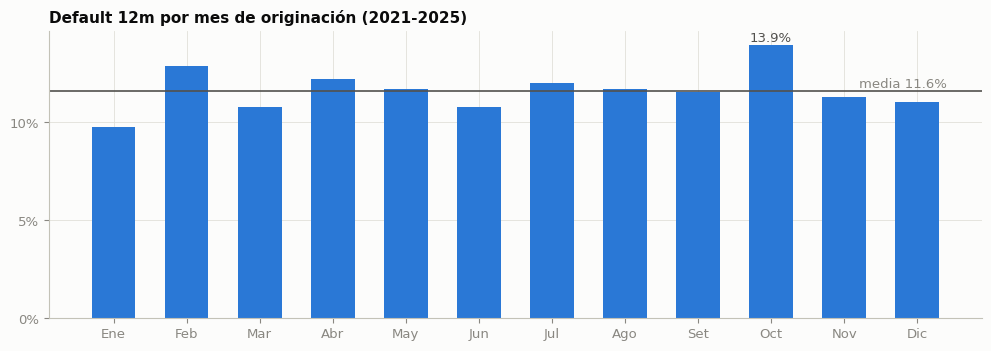

In [10]:
raw["mes"] = raw[cfg.DATE_COL].dt.month
perf["mes"] = perf[cfg.DATE_COL].dt.month
season = pd.DataFrame({"solicitudes": raw.groupby("mes").size(),
                       "aprobacion_ttd": raw.groupby("mes")[cfg.APPROVED_FLAG].mean(),
                       "default_rate_12m": perf.groupby("mes")[cfg.TARGET].mean()})
display(season.T)

fig, ax = plt.subplots(figsize=(10, 3.6))
meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Set", "Oct", "Nov", "Dic"]
ax.bar(meses, season["default_rate_12m"], color=BLUE, width=0.6)
ax.axhline(perf[cfg.TARGET].mean(), color=INK_2, lw=1.2)
ax.text(11.4, perf[cfg.TARGET].mean(), f"media {perf[cfg.TARGET].mean():.1%}", ha="right", va="bottom", color=MUTED)
imax = season["default_rate_12m"].values.argmax()
ax.text(imax, season["default_rate_12m"].iloc[imax], f"{season['default_rate_12m'].iloc[imax]:.1%}", ha="center", va="bottom", color=INK_2)
ax.set_title("Default 12m por mes de originación (2021-2025)"); pct_axis(ax)
fig.tight_layout()
savefig(fig, "fig04_estacionalidad")
plt.show()

El default varía entre 9.7% y 13.9% según el mes de originación (octubre es el mes más riesgoso y con menor aprobación, coincidente con el inicio de la campaña agrícola grande — hipótesis de negocio, no verificable con datos sintéticos). **Consecuencia:** cada muestra temporal debe cubrir años calendario completos para no sesgar la validación con una composición estacional distinta.

## 5. Sesgo de selección de la política histórica (6.2)

In [11]:
compare_cols = ["bureau_score", "prior_delinquencies_24m", "dti", "monthly_debt_payment", "annual_interest_rate_offer",
                "monthly_income", "cash_income_share", "distance_to_branch_km", "new_customer_flag", "requested_amount"]
sel = raw.groupby(cfg.APPROVED_FLAG)[compare_cols].mean().T.rename(columns={0: "rechazados", 1: "aprobados"})
sel["diferencia_%"] = sel["rechazados"] / sel["aprobados"] - 1
display(sel)

# Quintiles definidos sobre la población TTD y aplicados igual a aprobados (mismos cortes).
_, bq_edges = pd.qcut(raw["bureau_score"], 5, retbins=True)
bq_edges[0], bq_edges[-1] = -np.inf, np.inf
def bureau_quintile(s):
    q = pd.cut(s, bq_edges, labels=["Q1 (bajo)", "Q2", "Q3", "Q4", "Q5 (alto)"])
    return q.cat.add_categories("Sin score").fillna("Sin score")
raw["bq_ttd"], perf["bq_ttd"] = bureau_quintile(raw["bureau_score"]), bureau_quintile(perf["bureau_score"])
print("Cortes de buró (quintiles TTD):", np.round(bq_edges[1:-1], 0))
sel_bq = pd.DataFrame({"solicitudes": raw.groupby("bq_ttd", observed=True).size(),
                       "aprobacion_ttd": raw.groupby("bq_ttd", observed=True)[cfg.APPROVED_FLAG].mean(),
                       "aprobados_con_outcome": perf.groupby("bq_ttd", observed=True).size(),
                       "default_rate_aprobados": perf.groupby("bq_ttd", observed=True)[cfg.TARGET].mean()})
display(sel_bq)

sel_region = pd.DataFrame({"aprobacion_ttd": raw.groupby("region")[cfg.APPROVED_FLAG].mean(),
                           "default_rate_aprobados": perf.groupby("region")[cfg.TARGET].mean(),
                           "creditos_con_outcome": perf.groupby("region").size()})
display(sel_region)

# ¿Qué tan "explicable" es la decisión histórica con la información disponible?
Xh = raw[["bureau_score", "dti", "prior_delinquencies_24m", "bureau_inquiries_6m", "active_loans",
          "distance_to_branch_km", "cash_income_share"]]
Xh = (Xh.fillna(Xh.median()) - Xh.mean()) / Xh.std()
lr_hist = LogisticRegression(max_iter=1000).fit(Xh, raw[cfg.APPROVED_FLAG])
auc_hist = roc_auc_score(raw[cfg.APPROVED_FLAG], lr_hist.predict_proba(Xh)[:, 1])
print(f"AUC de un logit que replica la aprobación histórica: {auc_hist:.3f}")
print("Coeficientes estandarizados:", dict(zip(Xh.columns, lr_hist.coef_[0].round(3))))

approved_flag,rechazados,aprobados,diferencia_%
bureau_score,638.9043,670.7667,-0.0475
prior_delinquencies_24m,0.6130,0.5539,0.1067
dti,0.2973,0.2833,0.0497
monthly_debt_payment,"1,248.6665","1,162.1971",0.0744
annual_interest_rate_offer,0.3097,0.2920,0.0606
monthly_income,"4,161.6668","4,110.3088",0.0125
cash_income_share,0.5978,0.5958,0.0035
distance_to_branch_km,11.5845,12.3421,-0.0614
new_customer_flag,0.4503,0.4439,0.0144
requested_amount,"7,965.1664","7,876.2449",0.0113


Cortes de buró (quintiles TTD): [605. 647. 684. 728.]


,solicitudes,aprobacion_ttd,aprobados_con_outcome,default_rate_aprobados
bq_ttd,,,,
Q1 (bajo),1374,0.7358,1011,0.2473
Q2,1337,0.7861,1051,0.1503
Q3,1360,0.8404,1143,0.0954
Q4,1349,0.8703,1174,0.0818
Q5 (alto),1351,0.8964,1211,0.0372
Sin score,229,0.8428,193,0.0674


,aprobacion_ttd,default_rate_aprobados,creditos_con_outcome
region,,,
Centro,0.8285,0.1159,889
Lima,0.8344,0.1266,2394
Norte,0.8326,0.1210,1099
Oriente,0.7877,0.0947,549
Sur,0.8184,0.0939,852


AUC de un logit que replica la aprobación histórica: 0.624
Coeficientes estandarizados: {'bureau_score': np.float64(0.434), 'dti': np.float64(-0.085), 'prior_delinquencies_24m': np.float64(-0.084), 'bureau_inquiries_6m': np.float64(-0.014), 'active_loans': np.float64(0.002), 'distance_to_branch_km': np.float64(0.065), 'cash_income_share': np.float64(-0.01)}


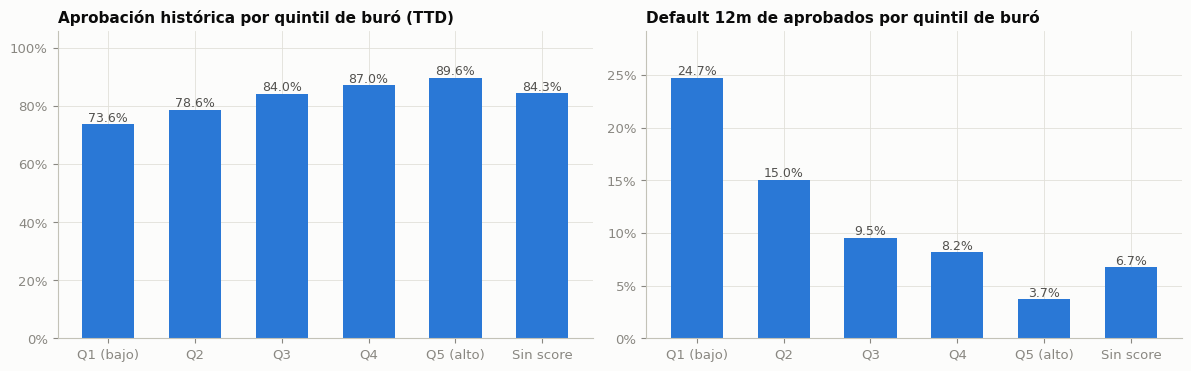

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
labels = sel_bq.index.astype(str)
for ax, col, title in [(axes[0], "aprobacion_ttd", "Aprobación histórica por quintil de buró (TTD)"),
                       (axes[1], "default_rate_aprobados", "Default 12m de aprobados por quintil de buró")]:
    ax.bar(labels, sel_bq[col], color=BLUE, width=0.6)
    for x, v in enumerate(sel_bq[col]):
        ax.text(x, v, f"{v:.1%}", ha="center", va="bottom", color=INK_2, fontsize=9)
    ax.set_title(title); pct_axis(ax)
    ax.set_ylim(0, sel_bq[col].max() * 1.18)
fig.tight_layout()
savefig(fig, "fig05_sesgo_seleccion")
plt.show()

**Lectura del sesgo de selección.**
- Los rechazados difieren sobre todo en buró (score medio 639 vs 671) y, en menor medida, en moras previas, DTI y tasa ofrecida. La política histórica fue un **filtro débil basado principalmente en buró** (AUC 0.62 al replicarla): incluso en el quintil más bajo se aprobó 73.6%.
- Consecuencia positiva: la muestra aprobada **sí cubre** la zona de alto riesgo (1,011 aprobados en el quintil más bajo de buró, con default de 24.7%), por lo que el modelo podrá aprender esa región. Consecuencia negativa: el 17.4% rechazado es sistemáticamente más riesgoso en buró y su default real es desconocido → la PD podría **subestimar** el riesgo de perfiles parecidos a los rechazados.
- **Oriente** tiene la menor aprobación (78.8%) y el menor default observado (9.5%). Parte puede ser efecto de selección (más filtro → mejor cartera), pero es una señal a vigilar en fair lending territorial.
- **Thin-file** (sin score): aprobación 84.3% y default 6.7% (13 de 193), pero con alta variabilidad por año (0% a 12.9%): evidencia insuficiente para tratarlos como bajo riesgo, suficiente para **no excluirlos**.

## 6. Capacidad de pago y Risk Appetite (6.1)

,solicitudes_%,aprobacion_ttd,default_rate_12m,creditos_con_outcome
dti_post,,,,
<=30%,0.2723,0.8366,0.0958,1556
30-45%,0.2994,0.8308,0.0936,1699
45-60%,0.2335,0.8107,0.1338,1293
60-80%,0.1471,0.8308,0.1677,835
>80%,0.0476,0.7846,0.1412,255


DTI post-crédito calculado con TEA de referencia 30% (no con la tasa ofrecida, que es endógena).


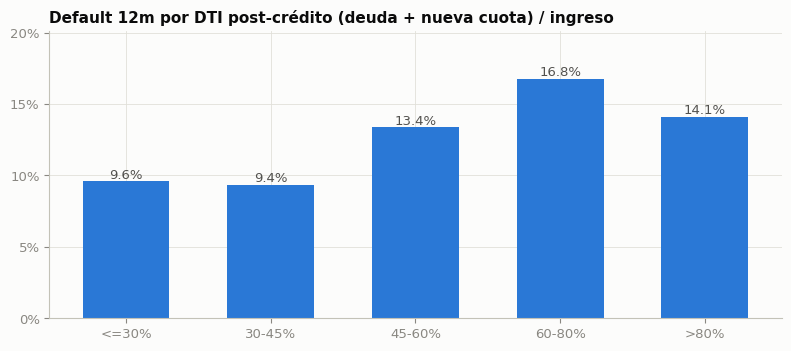

In [13]:
raw["dti_post"] = risk_appetite.dti_post(raw)
perf["dti_post"] = risk_appetite.dti_post(perf)
bands = [0, 0.30, cfg.DTI_POST_AUTO_MAX, cfg.DTI_POST_HARD_MAX, 0.80, np.inf]
band_lbl = ["<=30%", "30-45%", "45-60%", "60-80%", ">80%"]
cap = pd.DataFrame({
    "solicitudes_%": pd.cut(raw["dti_post"], bands, labels=band_lbl).value_counts(normalize=True).sort_index(),
    "aprobacion_ttd": raw.groupby(pd.cut(raw["dti_post"], bands, labels=band_lbl), observed=True)[cfg.APPROVED_FLAG].mean(),
    "default_rate_12m": perf.groupby(pd.cut(perf["dti_post"], bands, labels=band_lbl), observed=True)[cfg.TARGET].mean(),
    "creditos_con_outcome": perf.groupby(pd.cut(perf["dti_post"], bands, labels=band_lbl), observed=True).size(),
})
display(cap)
print(f"DTI post-crédito calculado con TEA de referencia {cfg.REFERENCE_ANNUAL_RATE:.0%} (no con la tasa ofrecida, que es endógena).")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(cap.index.astype(str), cap["default_rate_12m"], color=BLUE, width=0.6)
for x, v in enumerate(cap["default_rate_12m"]):
    ax.text(x, v, f"{v:.1%}", ha="center", va="bottom", color=INK_2)
ax.set_title("Default 12m por DTI post-crédito (deuda + nueva cuota) / ingreso"); pct_axis(ax)
ax.set_ylim(0, cap["default_rate_12m"].max() * 1.2)
fig.tight_layout()
savefig(fig, "fig07_default_por_dti_post")
plt.show()

El default se mantiene estable (~9.5%) mientras el DTI post-crédito no supera el 45%, pero salta a 13.4% en el tramo 45-60% y a 16.8% en el tramo 60-80%: duplicar la carga de deuda casi duplica el riesgo. En el último tramo (>80%) el default baja a 14.1%, aunque con una base pequeña (255 créditos) que no permite sacar conclusiones firmes.

La aprobación histórica, en cambio, apenas reacciona a esta señal: se mantiene entre 81% y 84% en los primeros cuatro tramos y recién cae a 78.5% cuando el DTI supera 80%. Esto confirma que la política anterior **no usaba la capacidad de pago como criterio de decisión**: el 42.8% de solicitudes con DTI post-crédito superior a 45% se aprobó casi igual que el resto. Por eso se propone una regla de capacidad explícita (paso 6 del ciclo) y un límite en el Risk Appetite.

### Risk Appetite: evaluación de la cartera histórica contra los umbrales propuestos

In [14]:
m_hist = risk_appetite.portfolio_metrics(raw)
m_2025 = risk_appetite.portfolio_metrics(raw[raw.year == 2025])
ra = risk_appetite.evaluate_appetite(m_hist).rename(columns={"valor": "historico_2021_2025", "semaforo": "semaforo_hist"})
ra["cosecha_2025"] = ra["key"].map(m_2025)
ra["semaforo_2025"] = [risk_appetite.traffic_light(v, d, g, r) for v, d, g, r in zip(ra.cosecha_2025, ra.direccion, ra.verde, ra.rojo)]
display(ra[["dimension", "metrica", "direccion", "verde", "rojo", "historico_2021_2025", "semaforo_hist", "cosecha_2025", "semaforo_2025"]])
ra.to_csv(cfg.TABLES / "risk_appetite.csv", index=False)

,dimension,metrica,direccion,verde,rojo,historico_2021_2025,semaforo_hist,cosecha_2025,semaforo_2025
0,Crecimiento,Tasa de aprobación sobre solicitudes (TTD),min,0.7000,0.6500,0.8261,Verde,0.8161,Verde
1,Riesgo,Default 12m (90+ DPD) de cosechas aprobadas,max,0.1100,0.1300,0.1160,Ámbar,0.1337,Rojo
2,Riesgo,Expected Loss / monto desembolsado (PD x EAD x...,max,0.0300,0.0350,0.0293,Verde,0.0337,Ámbar
3,Riesgo,LGD media de defaults,max,0.6500,0.7000,0.6229,Verde,0.6339,Verde
4,Concentración,Mayor participación de una macrorregión en el ...,max,0.4500,0.5000,0.4164,Verde,0.4067,Verde
5,Concentración,Participación del canal alianza en el monto,max,0.1500,0.2000,0.0958,Verde,0.1033,Verde
6,Concentración,Participación de clientes nuevos en el monto,max,0.5000,0.5500,0.4478,Verde,0.4494,Verde
7,Concentración,Participación de clientes sin score de buró en...,max,0.0500,0.0800,0.0318,Verde,0.0252,Verde
8,Concentración,Participación de plazos > 36 meses en el monto,max,0.2500,0.3000,0.2411,Verde,0.2244,Verde
9,Concentración,"Participación de montos > S/ 20,000 en el monto",max,0.1200,0.1500,0.1447,Ámbar,0.1573,Rojo


Se evalúan 14 métricas del Risk Appetite en dos momentos: el acumulado histórico (2021-2025) y solo la cosecha más reciente (2025), para ver si la cartera se está alejando del apetito.

**Crecimiento.** La aprobación se mantiene en Verde en ambos periodos (82.6% histórico, 81.6% en 2025): no hay señal de que la Caja esté restringiendo el acceso.

**Riesgo.** Aquí está el mayor deterioro. El default 12m pasa de Ámbar en el histórico (11.6%) a **Rojo en 2025 (13.4%)**, superando el límite de 13%. La Expected Loss lo acompaña: de Verde (2.9%) a Ámbar (3.4%). La LGD, en cambio, se mantiene en Verde en ambos casos (62.3% y 63.4%): la severidad no es el problema, es la frecuencia de default.

**Concentración.** Cinco de las seis métricas están en Verde y estables (macrorregión, alianza, clientes nuevos, thin-file, plazos largos, distancia). La excepción es el monto: la participación de créditos mayores a S/ 20,000 pasa de Ámbar (14.5%) a **Rojo (15.7%)**, es decir, la Caja está desembolsando cada vez más tickets fuera del rango de microcrédito.

**Capacidad de pago.** Es la métrica más crítica: el monto aprobado con DTI post-crédito superior a 60% está en **Rojo tanto en el histórico (21.6%) como en 2025 (22.2%)**, muy por encima del límite de 10%. Confirma que nunca se controló la capacidad de pago, ni siquiera en la cosecha más reciente.

**Fair lending.** El AIR (Adverse Impact Ratio) entre quintiles de ingreso en efectivo se mantiene en Verde (0.99 → 0.97): no hay indicio de discriminación por informalidad. Pero el AIR territorial entre macrorregiones cae de Verde (0.94) a **Ámbar (0.89)** en 2025, señal de que la brecha de aprobación entre regiones se está ampliando y debe monitorearse.

**En síntesis:** de las 14 métricas, 3 empeoraron de zona (default, monto grande y AIR territorial) y 2 ya estaban en Rojo desde el histórico y siguen ahí (capacidad de pago y, ahora también, default). El resto se mantiene estable en Verde.

In [15]:
pop, waterfall = data.pd_population(raw[RAW_COLS])
data.check_population(pop)
pop["year"] = pop[cfg.DATE_COL].dt.year
display(waterfall)
waterfall.to_csv(cfg.TABLES / "waterfall_poblacion.csv", index=False)
print(f"Población PD: {len(pop):,} créditos | defaults: {pop[cfg.TARGET].sum():,} | default rate: {pop[cfg.TARGET].mean():.2%}")

,paso,criterio,excluidos,remanentes,pct_base
0,0,Solicitudes en data.csv,0,7000,1.0000
1,1,Duplicados de application_id,0,7000,1.0000
2,2,observation_date nula o fuera de 2021-2025,0,7000,1.0000
3,3,Rechazados por la política histórica (approved...,1217,5783,0.8261
4,4,Aprobados sin ventana de performance (outcome_...,0,5783,0.8261
5,5,Target nulo o no binario,0,5783,0.8261
6,6,Edad < 18 (fuera de elegibilidad legal),0,5783,0.8261


Población PD: 5,783 créditos | defaults: 671 | default rate: 11.60%


In [16]:
# Indeterminados: ¿existe información de mora intermedia (30-89 DPD) o de curas?
dpd_like = [c for c in raw.columns if any(k in c.lower() for k in ["dpd", "days_past", "max_mora", "cure", "arrear"])]
print("Columnas de mora intermedia/curas disponibles:", dpd_like or "ninguna -> no es posible construir un segmento indeterminado")

# Madurez de la ventana: una ventana incompleta produciría un default artificialmente bajo en las últimas cosechas.
q = pop.groupby(pop[cfg.DATE_COL].dt.to_period("Q"))[cfg.TARGET].agg(["size", "mean"]).tail(6)
display(q.rename(columns={"size": "creditos", "mean": "default_rate_12m"}))
mature = pop[(pop["sample"] == "OOT") & (pop[cfg.DATE_COL] <= cfg.OOT_MATURE_END)]
print(f"OOT con ventana cumplida a la fecha de elaboración (ene-ago 2025): {len(mature):,} créditos, default {mature[cfg.TARGET].mean():.2%}")

Columnas de mora intermedia/curas disponibles: ninguna -> no es posible construir un segmento indeterminado


,creditos,default_rate_12m
observation_date,,
2024Q3,337,0.1335
2024Q4,275,0.1709
2025Q1,286,0.1434
2025Q2,305,0.1180
2025Q3,308,0.1169
2025Q4,290,0.1586


OOT con ventana cumplida a la fecha de elaboración (ene-ago 2025): 801 créditos, default 12.86%


- **Indeterminados:** el archivo no trae mora máxima ni curas, por lo que no es posible separar un segmento indeterminado (p. ej., 30-89 DPD). El target es binario puro; "buenos" incluye créditos con mora leve que nunca llegaron a 90 días.
- **Madurez:** las últimas cosechas **no** muestran la caída de default típica de una ventana truncada (2025T4 = 15.9%). Se acepta el supuesto de ventana completa; como control adicional puede evaluarse el OOT restringido a ene-ago 2025 (cosechas ya maduras a la fecha de elaboración).

## 8. Esquema temporal DEV / VAL / OOT (6.2)

In [17]:
split = data.sample_summary(pop)
raw["sample"] = data.assign_sample(raw[cfg.DATE_COL])
split["solicitudes_ttd"] = raw.groupby("sample").size()
split["aprobacion_ttd"] = raw.groupby("sample")[cfg.APPROVED_FLAG].mean()
split["se_auc_si_auc_0.70"] = [validation.auc_standard_error(0.70, int(b), int(n - b)) for n, b in zip(split.n, split.defaults)]
split["uso"] = ["Ajuste del modelo (entrenamiento y tuning)", "Comparación de modelos y calibración",
                "Evaluación final, sin usarse en ninguna decisión previa"]
display(split)
split.to_csv(cfg.TABLES / "split_temporal.csv")

,desde,hasta,n,defaults,default_rate,pct_n,pct_defaults,solicitudes_ttd,aprobacion_ttd,se_auc_si_auc_0.70,uso
sample,,,,,,,,,,,
DEV,2021-01-01,2023-12-27,3443,351,0.1019,0.5954,0.5231,4154,0.8288,0.0162,Ajuste del modelo (entrenamiento y tuning)
VAL,2024-01-01,2024-12-27,1151,161,0.1399,0.1990,0.2399,1389,0.8287,0.0242,Comparación de modelos y calibración
OOT,2025-01-01,2025-12-27,1189,159,0.1337,0.2056,0.2370,1457,0.8161,0.0243,"Evaluación final, sin usarse en ninguna decisi..."


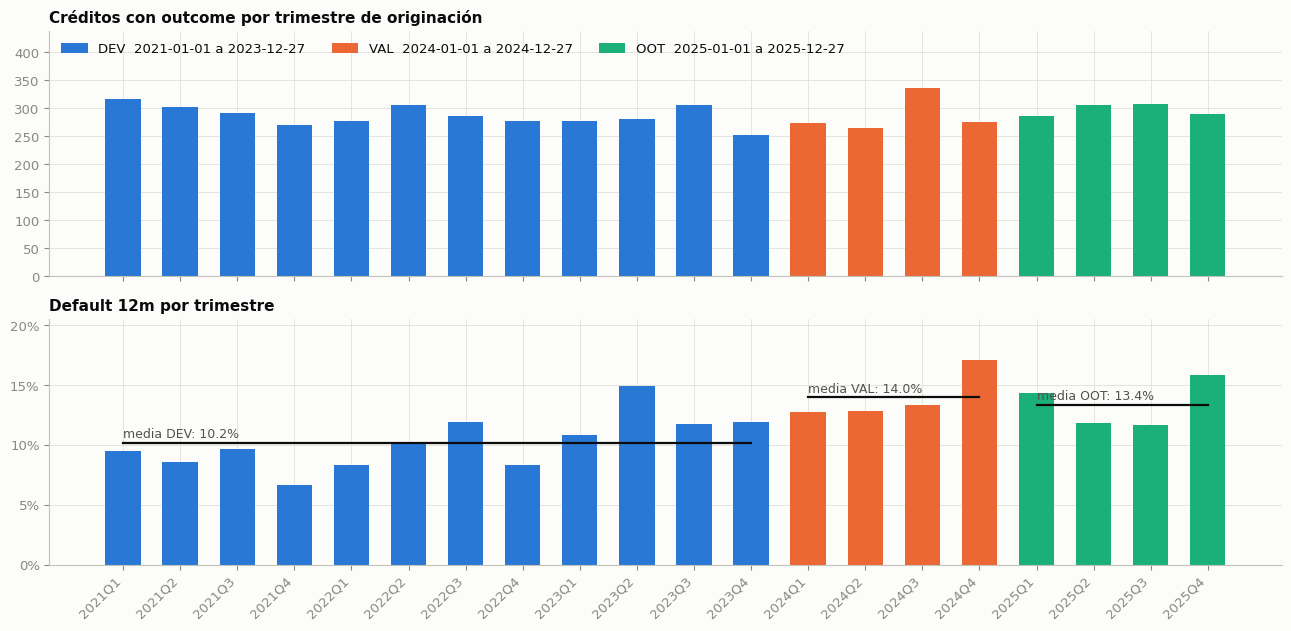

In [18]:
qtab = pop.groupby([pop[cfg.DATE_COL].dt.to_period("Q"), "sample"]).agg(n=(cfg.TARGET, "size"), dr=(cfg.TARGET, "mean")).reset_index()
qtab["q"] = qtab[cfg.DATE_COL].astype(str)
fig, axes = plt.subplots(2, 1, figsize=(13, 6.4), sharex=True)
for s in cfg.SAMPLE_ORDER:
    d = qtab[qtab["sample"] == s]
    axes[0].bar(d["q"], d["n"], color=SAMPLE_COLORS[s], width=0.62, label=f"{s}  {split.loc[s, 'desde']} a {split.loc[s, 'hasta']}")
    axes[1].bar(d["q"], d["dr"], color=SAMPLE_COLORS[s], width=0.62)
    xs = d["q"].tolist()
    axes[1].plot([xs[0], xs[-1]], [split.loc[s, "default_rate"]] * 2, color=INK, lw=1.6)
    axes[1].text(xs[0], split.loc[s, "default_rate"] + 0.004, f"media {s}: {split.loc[s, 'default_rate']:.1%}", color=INK_2, fontsize=9)
axes[0].set_title("Créditos con outcome por trimestre de originación")
axes[0].legend(loc="upper left", ncol=3)
axes[0].set_ylim(0, qtab["n"].max() * 1.3)
axes[1].set_title("Default 12m por trimestre"); pct_axis(axes[1])
axes[1].set_ylim(0, qtab["dr"].max() * 1.2)
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()
savefig(fig, "fig06_split_temporal")
plt.show()

In [19]:
# ¿Por qué no un split aleatorio? El aleatorio "promedia" los años y esconde el cambio de nivel.
rng = np.random.default_rng(cfg.SEED)
is_test = rng.random(len(pop)) < 0.25
demo = pd.DataFrame({
    "default_train": [pop.loc[~is_test, cfg.TARGET].mean(), pop.loc[pop["sample"] == "DEV", cfg.TARGET].mean()],
    "default_test": [pop.loc[is_test, cfg.TARGET].mean(), pop.loc[pop["sample"] == "OOT", cfg.TARGET].mean()],
}, index=["Aleatorio 75/25", "Temporal DEV -> OOT"])
demo["brecha_relativa"] = demo["default_test"] / demo["default_train"] - 1
display(demo)

,default_train,default_test,brecha_relativa
Aleatorio 75/25,0.1169,0.1136,-0.0285
Temporal DEV -> OOT,0.1019,0.1337,0.3117


Con un split aleatorio, entrenamiento y prueba tienen prácticamente el mismo default (11.7% vs 11.4%) y el modelo parecería perfectamente calibrado; con el split temporal aparece la brecha real de **+31%** entre el nivel de riesgo de desarrollo y el de la cosecha más reciente. Esa es la situación que enfrentará el modelo en producción.

**Estabilidad de la población entre muestras (PSI vs DEV):**

In [20]:
cands = data.pd_candidate_features()
cat_feats = ["region", "channel", "employment_type"]
rows = []
for f in cands:
    ref, val, oot = (pop.loc[pop["sample"] == s, f] for s in cfg.SAMPLE_ORDER)
    fn = validation.psi_categorical if f in cat_feats else validation.psi
    rows.append({"variable": f, "psi_val": fn(ref, val), "psi_oot": fn(ref, oot)})
psi_tab = pd.DataFrame(rows).sort_values("psi_oot", ascending=False)
psi_tab["semaforo_oot"] = psi_tab["psi_oot"].map(validation.psi_label)
display(psi_tab)
psi_tab.to_csv(cfg.TABLES / "psi_variables_split.csv", index=False)

stab = []
for f, sign in [("bureau_score", -1), ("dti", 1), ("annual_interest_rate_offer", 1)]:
    row = {"variable": f}
    for y, g in pop.groupby("year"):
        row[y] = validation.univariate_auc(g[cfg.TARGET], sign * g[f])
    stab.append(row)
display(pd.DataFrame(stab).set_index("variable").rename_axis("AUC univariado por año"))

,variable,psi_val,psi_oot,semaforo_oot
0,age,0.0143,0.0174,Verde
15,requested_amount,0.0088,0.0128,Verde
5,employment_tenure_months,0.0200,0.0128,Verde
6,bureau_score,0.0065,0.0114,Verde
11,dti,0.0025,0.0100,Verde
12,savings_balance,0.0066,0.0098,Verde
4,monthly_income,0.0104,0.0077,Verde
2,channel,0.0023,0.0072,Verde
14,relationship_months,0.0083,0.0055,Verde
19,cash_income_share,0.0066,0.0055,Verde


,2021,2022,2023,2024,2025
AUC univariado por año,,,,,
bureau_score,0.7031,0.6724,0.7031,0.6733,0.7074
dti,0.5945,0.5735,0.5531,0.5328,0.6131
annual_interest_rate_offer,0.5695,0.5882,0.6311,0.6104,0.6410


Todas las variables candidatas tienen **PSI ≤ 0.02** entre DEV y VAL/OOT (verde): la población que llega no cambia. Además, el poder discriminante del buró es estable (AUC 0.67-0.71 por año). Por lo tanto, lo que el OOT medirá es la **estabilidad de la relación riesgo-variables y la calibración ante el cambio de nivel**, que es exactamente la prueba relevante para este caso.

## 9. Variables disponibles en el momento de la decisión (6.2)

In [21]:
catalog = data.variable_catalog(dic)
catalog["pct_faltante"] = catalog["variable"].map(raw.isna().mean())
display(catalog[["variable", "rol", "fuente", "momento", "disponible_T0", "uso_pd", "uso_oficial", "pct_faltante"]])
catalog.to_csv(cfg.TABLES / "catalogo_variables.csv", index=False)

print("Candidatas PD:", len(data.pd_candidate_features()), "->", data.pd_candidate_features())
print("Sujetas a revisión de fairness:", data.fairness_review_features())
print("Prohibidas como predictor PD:", data.forbidden_pd_features())

,variable,rol,fuente,momento,disponible_T0,uso_pd,uso_oficial,pct_faltante
0,application_id,ID,Sistema de originación,T0,Sí,No,No,0.0000
1,observation_date,Tiempo,Sistema de originación,T0,Sí,No,Si,0.0000
2,entity,Metadato,Constante,T0,Sí,No,No,0.0000
3,product,Metadato,Constante,T0,Sí,No,No,0.0000
4,age,Solicitud,Documento de identidad / RENIEC,T0,Sí,Candidata (fairness),Si,0.0000
5,region,Solicitud,Dirección declarada,T0,Sí,Candidata (fairness),Si,0.0000
6,channel,Proceso,Canal de captación,T0,Sí,Candidata,Si,0.0000
7,employment_type,Solicitud,Declarado,T0,Sí,Candidata,Si,0.0000
8,monthly_income,Solicitud,Declarado / estimado por asesor,T0,Sí,Candidata,Si,0.0243
9,employment_tenure_months,Solicitud,Declarado,T0,Sí,Candidata,Si,0.0000


Candidatas PD: 20 -> ['age', 'region', 'channel', 'employment_type', 'monthly_income', 'employment_tenure_months', 'bureau_score', 'prior_delinquencies_24m', 'bureau_inquiries_6m', 'active_loans', 'monthly_debt_payment', 'dti', 'savings_balance', 'new_customer_flag', 'relationship_months', 'requested_amount', 'term_months', 'distance_to_branch_km', 'household_dependents', 'cash_income_share']
Sujetas a revisión de fairness: ['age', 'region', 'distance_to_branch_km', 'household_dependents', 'cash_income_share']
Prohibidas como predictor PD: ['annual_interest_rate_offer', 'approved_flag', 'outcome_available_flag', 'default_12m_flag', 'ead_at_default', 'balance_at_default', 'recovery_amount_total', 'recovery_cost_total', 'months_to_recovery', 'lgd_observed']


In [22]:
# Evidencia para excluir annual_interest_rate_offer del PD: es output de la política de riesgo previa.
rate = raw[["annual_interest_rate_offer", "bureau_score", "dti", "prior_delinquencies_24m"]].corr(method="spearman")["annual_interest_rate_offer"]
display(rate.rename("Spearman vs tasa ofrecida").to_frame())
display(perf.groupby(pd.qcut(perf["annual_interest_rate_offer"], 5), observed=True)[cfg.TARGET].agg(["size", "mean"])
        .rename(columns={"size": "creditos", "mean": "default_rate_12m"}))

,Spearman vs tasa ofrecida
annual_interest_rate_offer,1.0000
bureau_score,-0.4314
dti,0.1454
prior_delinquencies_24m,0.0729


,creditos,default_rate_12m
annual_interest_rate_offer,,
"(0.0887, 0.232]",1160,0.0733
"(0.232, 0.272]",1153,0.0841
"(0.272, 0.308]",1158,0.1054
"(0.308, 0.349]",1157,0.1296
"(0.349, 0.639]",1155,0.1879


La tasa ofrecida está correlacionada con el buró (−0.43) y ordena el default de 7.3% a 18.8%, con AUC creciente en el tiempo (0.57 → 0.64): **incorpora la evaluación de riesgo de la política anterior**. Usarla como predictor sería circular (el modelo aprendería la decisión que debe reemplazar) y la volvería inválida si cambia el pricing. Se excluye del PD y se reserva para el análisis de pricing.

## 10. Persistencia y resumen de decisiones

In [23]:
pop.drop(columns=["year"], errors="ignore").to_csv(cfg.DATA_PROCESSED / "pd_population.csv", index=False)
print("Guardado: data/processed/pd_population.csv", pop.drop(columns=["year"]).shape)
print("Tablas:", sorted(p.name for p in cfg.TABLES.glob("*.csv")))
print("Figuras:", sorted(p.name for p in cfg.FIGURES.glob("*.png")))

Guardado: data/processed/pd_population.csv (5783, 42)
Tablas: ['catalogo_variables.csv', 'linea_base_anual.csv', 'perfil_producto_numerico.csv', 'psi_variables_split.csv', 'risk_appetite.csv', 'split_temporal.csv', 'waterfall_poblacion.csv']
Figuras: ['fig01_ciclo_credito.png', 'fig02_perfil_producto_cliente.png', 'fig03_linea_base_anual.png', 'fig04_estacionalidad.png', 'fig05_sesgo_seleccion.png', 'fig06_split_temporal.png', 'fig07_default_por_dti_post.png']


| Decisión | Definición adoptada | Evidencia |
|---|---|---|
| Decisión que resuelve el modelo | PD 12m de originación para APPROVE / REVIEW / REJECT, pricing y monto | Sección 3 |
| Target | `default_12m_flag`: 90+ DPD en (T0, T0+12m] | Enunciado 5.2 |
| Observation date | `observation_date` = fecha de originación; predictores medidos en T0 | Sección 9 |
| Performance window | 12 meses | Sección 7 |
| Población PD | 5,783 aprobados con outcome (671 defaults, 11.60%) | Waterfall |
| Exclusión principal | 1,217 rechazados (sin performance; nunca como "buenos") | Sección 5 y 7 |
| Esquema temporal | DEV 2021-2023 · VAL 2024 · OOT 2025 | Sección 8 |
| Variable excluida por endogeneidad | `annual_interest_rate_offer` | Sección 9 |
| Variables con revisión de fairness | `age`, `region`, `distance_to_branch_km`, `household_dependents`, `cash_income_share` | Catálogo |
| Risk Appetite | 14 métricas con semáforo; cosecha 2025 en rojo en default, tickets grandes y capacidad de pago | Sección 6 |